# CUSTOMER RETENTION & CHURN ANALYSIS
# BY COLINS NDWIGA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

## Data Source: I downloaded the dataset from https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [2]:
df=pd.read_csv('Customer_data.csv',low_memory=False)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Checking for Missing Values

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with 0 (new customers with tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [7]:
# Convert Churn to binary (1 = churned, 0 = retained)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [8]:
df['AvgMonthly'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

In [9]:
df.shape

(7043, 22)

In [10]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
AvgMonthly          float64
dtype: object

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthly
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000


## Looking at the Overall Churn Rate

In [12]:
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Total Customers: {len(df)}")
print(f"Churned Customers: {df['Churn'].sum()}")

Overall Churn Rate: 26.54%
Total Customers: 7043
Churned Customers: 1869


### Plotting Churn by Contract Type

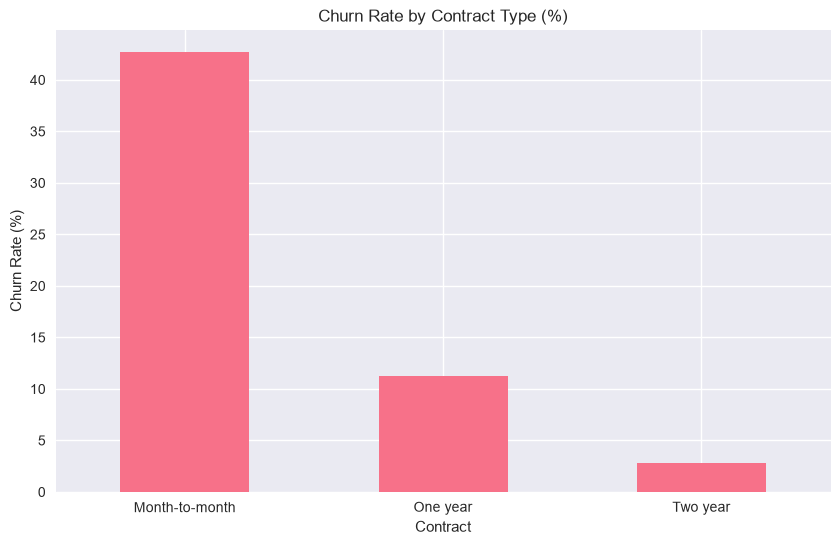

In [13]:
plt.figure(figsize=(10, 6))
churn_by_contract = df.groupby('Contract')['Churn'].mean() * 100
churn_by_contract.plot(kind='bar')
plt.title('Churn Rate by Contract Type (%)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [14]:
print(churn_by_contract)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


### Key Insight
### Month-to-month contracts have dramatically higher churn (42.71%) compared to one-year (11.3%) and two-year contracts (2.8%). This is the "strongest churn driver" in the dataset.

### Plotting Churn by Tenure

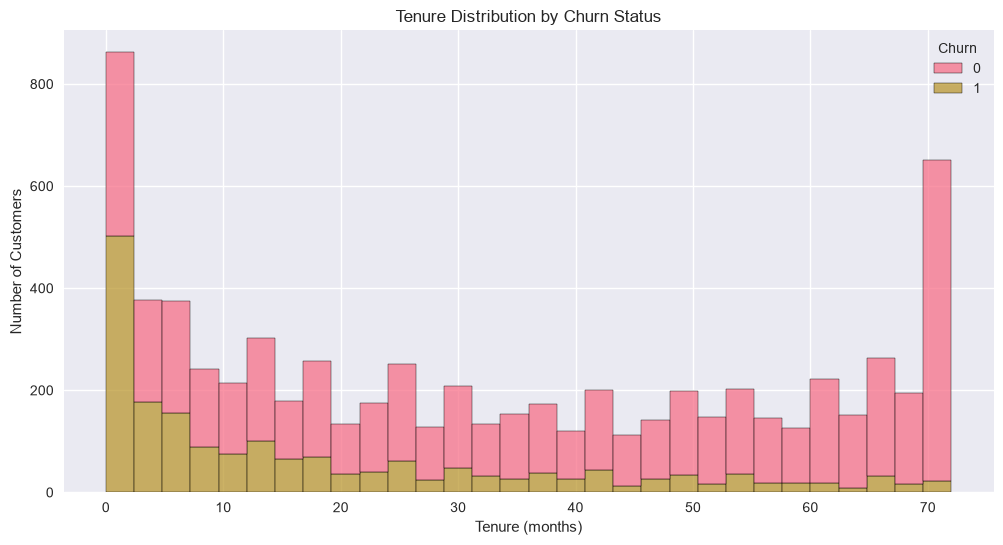

TenureGroup
0-6      53.333333
7-12     35.886525
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64


In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

# Churn rate by tenure groups
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72], 
                           labels=['0-6', '7-12', '13-24', '25-48', '49-72'])
print(df.groupby('TenureGroup')['Churn'].mean() * 100)

### Key Insight
### Churn is heavily concentrated in the "early months". Customers with tenure under 6 months have an over 53% churn rate, dropping significantly after 12 months. Early customer experience is critical.

### Plotting Churn by Payment Method & Internet Service

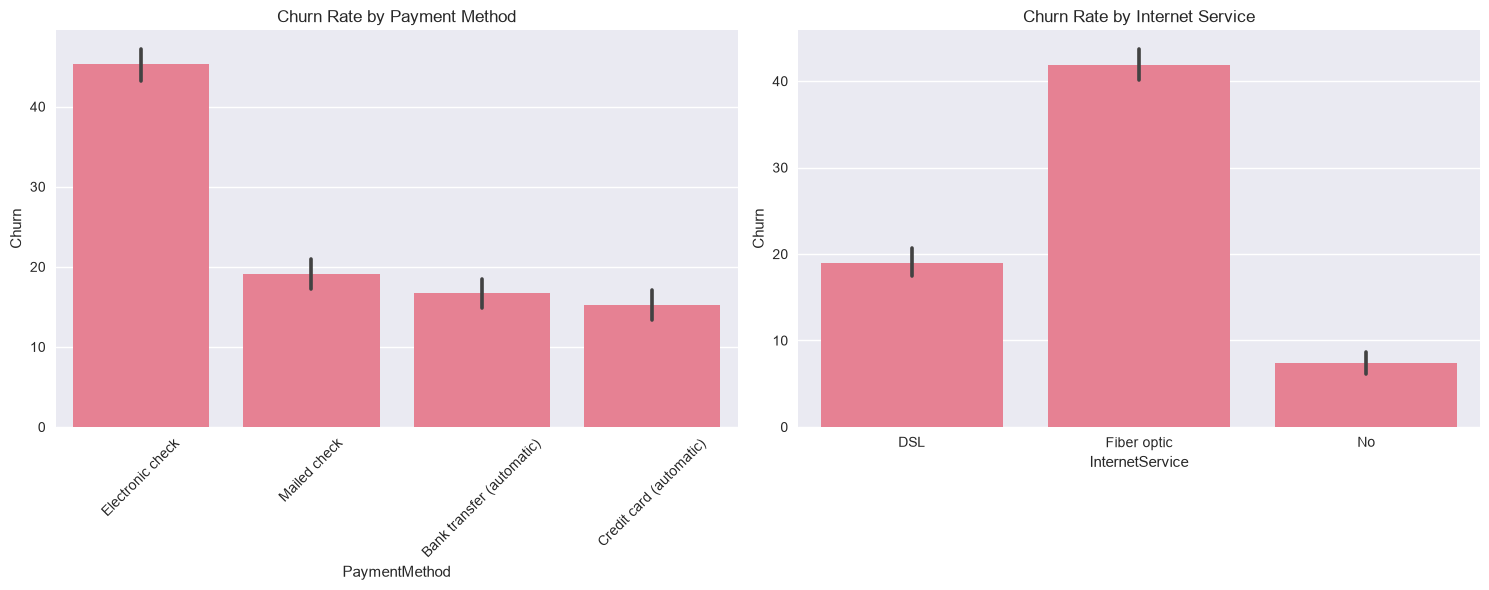

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Payment Method
sns.barplot(x='PaymentMethod', y='Churn', data=df, ax=axes[0], estimator=lambda x: sum(x)/len(x)*100)
axes[0].set_title('Churn Rate by Payment Method')
axes[0].tick_params(axis='x', rotation=45)

# Internet Service
sns.barplot(x='InternetService', y='Churn', data=df, ax=axes[1], estimator=lambda x: sum(x)/len(x)*100)
axes[1].set_title('Churn Rate by Internet Service')

plt.tight_layout()
plt.show()

### Key Insight
### Electronic check users churn at much higher rates. Fiber optic customers also show elevated churn compared to DSL,
### likely due to higher expectations and pricing sensitivity.

### Plotting churn by Monthly Charges & Demographics

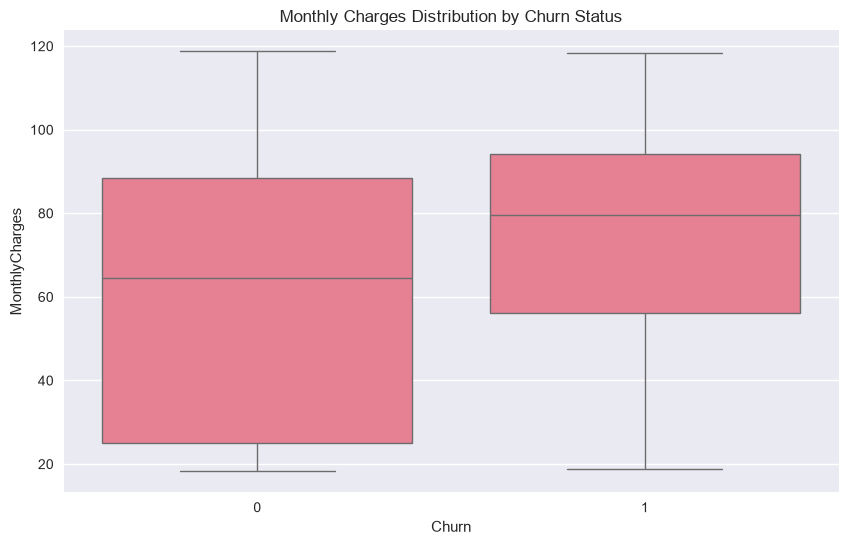

Churn Rate by Senior Citizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64


In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

# Churn by Senior Citizen
print("Churn Rate by Senior Citizen:")
print(df.groupby('SeniorCitizen')['Churn'].mean() * 100)

### Key Insight
### Churned customers tend to have "higher monthly charges". Senior citizens also churn at nearly double the rate (41.7% vs 23.6%), indicating they may be more price-sensitive.

### Impact of Service Usage on Customer Churn

In [18]:
# Convert service columns to binary
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in services:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

# Correlation with churn
service_corr = df[services + ['Churn']].corr()['Churn'].sort_values(ascending=False)
print("Service Correlation with Churn:")
print(service_corr)

Service Correlation with Churn:
Churn               1.000000
StreamingTV         0.063228
StreamingMovies     0.061382
DeviceProtection   -0.066160
OnlineBackup       -0.082255
TechSupport        -0.164674
OnlineSecurity     -0.171226
Name: Churn, dtype: float64


### Key Insight
### Having "Online Security" and "Tech Support" strongly reduces churn. Streaming services have minimal impact. Bundling protective services is a powerful retention strategy.

## Cohort Analysis (Retention by Signup Period)

In [20]:
df['Cohort'] = pd.cut(df['tenure'], 
                      bins=[0, 3, 6, 12, 24, 36, 72], 
                      labels=['0-3m', '4-6m', '7-12m', '13-24m', '25-36m', '37+m'])

# Churn rate by cohort
cohort_churn = df.groupby('Cohort')['Churn'].agg(['count', 'mean']).round(3)
cohort_churn['Churn_Rate_%'] = cohort_churn['mean'] * 100
print("Cohort Analysis - Churn by Tenure Group:")
display(cohort_churn)

Cohort Analysis - Churn by Tenure Group:


,count,mean,Churn_Rate_%
Cohort,,,
0-3m,1051,0.568,56.8
4-6m,419,0.446,44.6
7-12m,705,0.359,35.9
13-24m,1024,0.287,28.7
25-36m,832,0.216,21.6
37+m,3001,0.119,11.9


### Key Insight
### Churn risk decreases sharply with longer tenure. Customers in the first 3 months have a 56.8% churn rate, while those with 37+ months have only a 11.9% churn rate. Retention improves dramatically over time.

### Retention Curve 

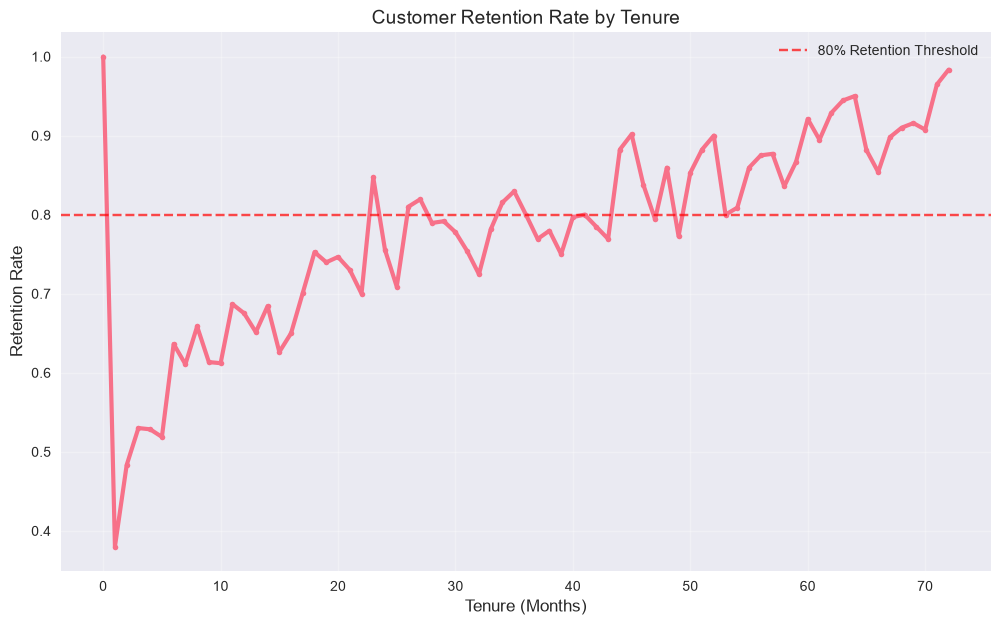

In [21]:
plt.figure(figsize=(12, 7))

# Retention rate by tenure
retention_rate = 1 - df.groupby('tenure')['Churn'].mean()

plt.plot(retention_rate.index, retention_rate.values, linewidth=3, marker='o', markersize=4)
plt.title('Customer Retention Rate by Tenure', fontsize=14)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Retention Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% Retention Threshold')
plt.legend()
plt.show()


### Key Insight
### Retention rate improves with tenure but drops sharply in the first few months. The 80% retention threshold is crossed around 20–23 months. Focus on early engagement is essential.

## Customer Lifetime Value (CLV) Estimation

Average CLV - Retained Customers: $2,549.77
Average CLV - Churned Customers: $1,531.61
Potential Lost Revenue per Churned Customer: $1,018.16


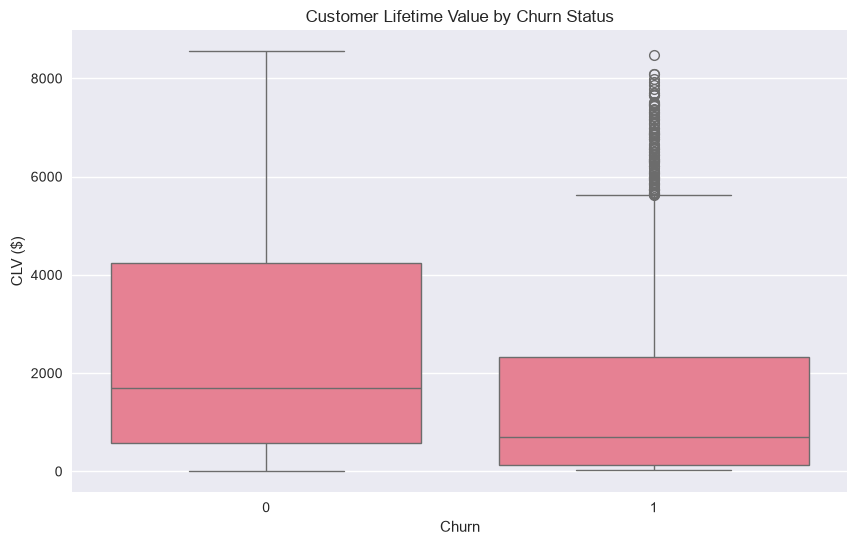

In [22]:
# Simple CLV = MonthlyCharges * Tenure (for current customers)
df['CLV'] = df['MonthlyCharges'] * df['tenure']

# CLV comparison
clv_retained = df[df['Churn'] == 0]['CLV'].mean()
clv_churned = df[df['Churn'] == 1]['CLV'].mean()

print(f"Average CLV - Retained Customers: ${clv_retained:,.2f}")
print(f"Average CLV - Churned Customers: ${clv_churned:,.2f}")
print(f"Potential Lost Revenue per Churned Customer: ${clv_retained - clv_churned:,.2f}")

# Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='CLV', data=df)
plt.title('Customer Lifetime Value by Churn Status')
plt.ylabel('CLV ($)')
plt.show()

### Key Insight
### Retained customers generate significantly higher lifetime value ($2,550 vs $1,532 for churned). Each prevented churn saves over $1,000 in lost revenue on average.

### Correlation HeatMap

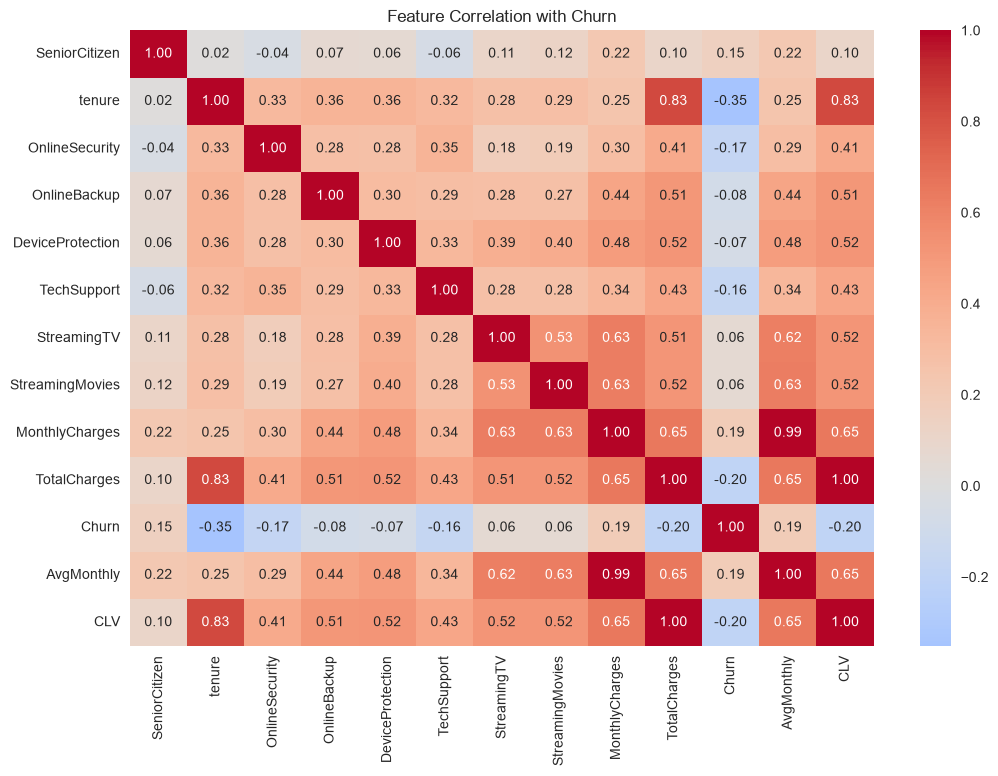

In [23]:
plt.figure(figsize=(12, 8))

# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation with Churn')
plt.show()

### Key Insight
### Tenure has the strongest negative correlation with churn. Contract type, total charges, and monthly charges are also major factors. Longer relationships and better service bundles drive retention.

## Building our Churn Prediction Model

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Preparing our Features

In [25]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 
            'Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']

# Create dummy variables for categorical features
df_model = pd.get_dummies(df[features], drop_first=True)

X = df_model
y = df['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 5282 samples
Test set: 1761 samples


### Training our Model

In [26]:
# Train Random Forest Model
model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print("Model Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 80.58 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1282
           1       0.69      0.53      0.60       479

    accuracy                           0.81      1761
   macro avg       0.76      0.72      0.73      1761
weighted avg       0.80      0.81      0.80      1761



### Feature Importance

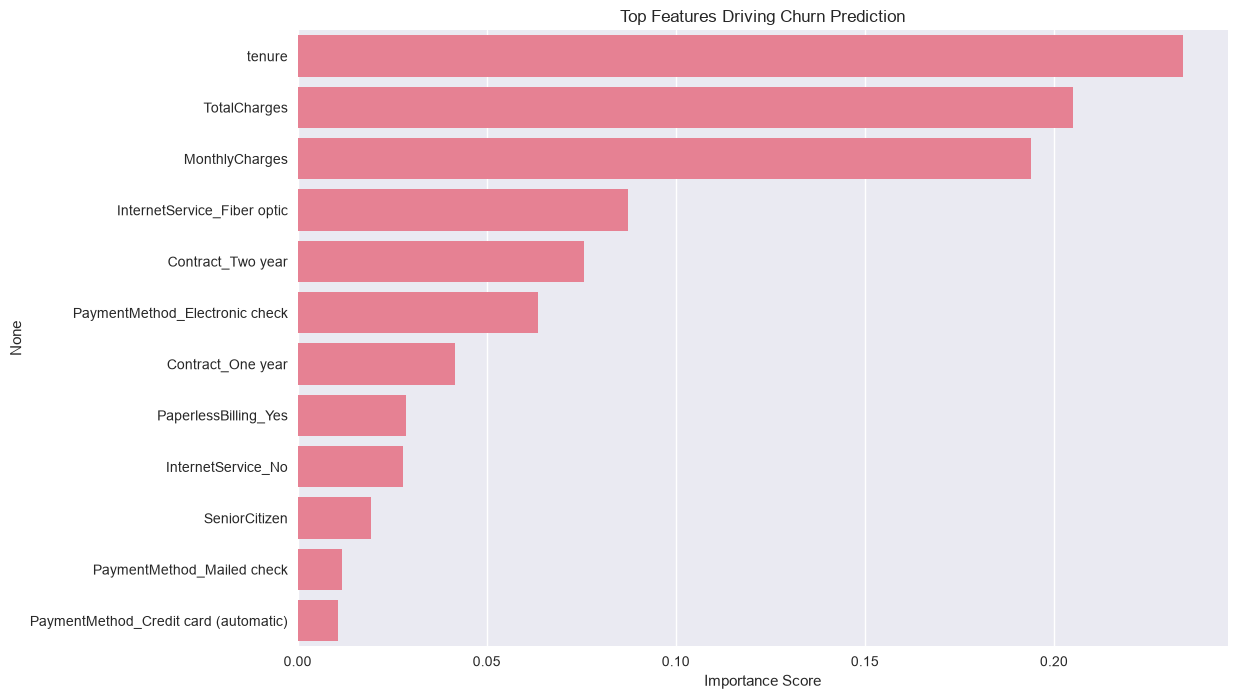

Top 10 Most Important Features:
tenure                            0.234212
TotalCharges                      0.204911
MonthlyCharges                    0.193997
InternetService_Fiber optic       0.087332
Contract_Two year                 0.075767
PaymentMethod_Electronic check    0.063545
Contract_One year                 0.041510
PaperlessBilling_Yes              0.028784
InternetService_No                0.027975
SeniorCitizen                     0.019320
dtype: float64


In [27]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title('Top Features Driving Churn Prediction')
plt.xlabel('Importance Score')
plt.show()

print("Top 10 Most Important Features:")
print(importances.head(10))

### Key Insight
### The model confirms tenure, total charges, and monthly charges as top predictors.
### Contract type (especially Two-year) and Fiber optic service are also highly influential.

### Confusion Matrix

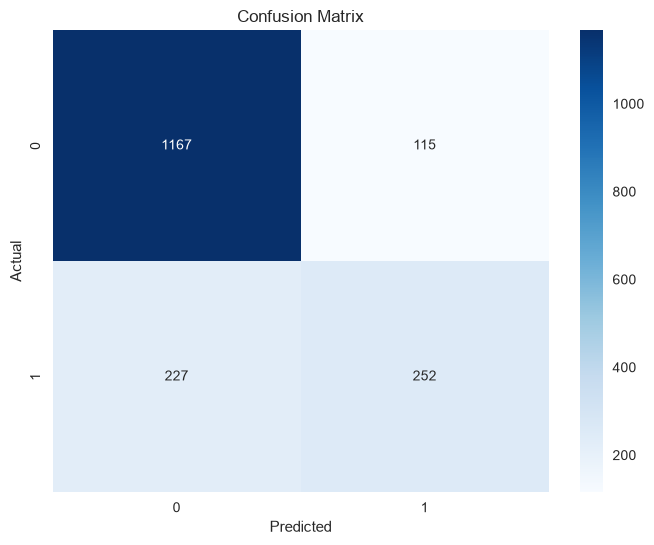

In [28]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Key Insight
### The Random Forest model achieves 80.6% accuracy. 
### It is better at predicting retained customers but still identifies many at-risk ones. 
### This can be used for proactive retention campaigns.

# SUMMARY OF KEY FINDINGS
### Churn Rate: 26.54%
### Average Customer Tenure: 32.4 months
### KEY CHURN PATTERNS
### • Month-to-month contracts have 42.7% churn rate
### • New customers (first 12 months) are at the highest risk
### • Electronic check payment method shows elevated churn
### • Lack of additional services (Security, Tech Support) increases churn

### RETENTION OPPORTUNITIES
### • Strongest retention driver: Longer contract terms
### • High-value services (Tech Support, Online Security) reduce churn
### • Automatic payments significantly improve loyalty



## RECOMMENDATIONS
### 1. Launch contract upgrade campaign for month-to-month users to upgrade to Annual contracts 
### 2. Enhance onboarding & engagement in the first 6 months
### 3. Promote service bundles (Security + Support)
### 4. Incentivize automatic payment methods
### 5. Use the predictive model to identify at-risk customers for proactive outreach

### Reducing churn by 5–10% could significantly increase revenue and customer lifetime value.